# EXPERIMENT 4: DATA WRANGLING AND DATA VISUALIZATION 

by MIGUEL, Letizha Martha C. | Section: 2ECE-D

This experiment focuses on data wrangling and visualization techniques. Key objectives include filtering tabular data using both categorical and numerical conditions, constructing focused DataFrames with relevant features, summarizing relationships between categorical features and numerical variables, and effectively communicating data comparisons through clearly labeled plots.

In [28]:
import pandas as pd

In [29]:
import matplotlib.pyplot as plt

In [30]:
 df_excel = pd.read_excel('board2.xlsx')

In [31]:
df_excel['Average']=df_excel[['Math','Electronics','GEAS', 'Communication']].mean(axis=1)
df_excel

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


**A. VISAYAS COMMUNICATION DATAFRAME**

In [32]:
df_excel['Average'] = df_excel[['Math', 'Electronics', 'GEAS']].mean(axis=1)

VisComm = df_excel[(df_excel['Hometown'] == 'Visayas') & (df_excel['Track'] == 'Communication')]

VisComm = VisComm[['Name', 'Gender', 'Math', 'Electronics', 'Average']]

display(VisComm)

print("Number of rows in VisComm:", len(VisComm))

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,50.666667
11,S12,Male,89,67,80.000000
17,S18,Male,81,40,67.333333
21,S22,Female,64,39,64.000000
27,S28,Male,85,53,72.666667


Number of rows in VisComm: 5


**B. VISAYAS FEMALE DATAFRAME**

In [33]:
df_excel['Average'] = df_excel[['Math', 'Electronics', 'GEAS']].mean(axis=1)

VisFemale = df_excel[(df_excel['Hometown'] == 'Visayas') & (df_excel['Gender'] == 'Female')]

VisFemale = VisFemale[['Name', 'Track', 'GEAS', 'Electronics', 'Average']]

display(VisFemale)

print('\nRows of VisFemale with Average at least 60:')
display(VisFemale[VisFemale['Average'] >= 60])

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,73.000000
10,S11,Communication,48,56,50.666667
20,S21,Microelectronics,68,51,67.333333
21,S22,Communication,89,39,64.000000
23,S24,Microelectronics,60,45,63.333333
25,S26,Instrumentation,83,47,67.000000



Rows of VisFemale with Average at least 60:


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,73.000000
20,S21,Microelectronics,68,51,67.333333
21,S22,Communication,89,39,64.000000
23,S24,Microelectronics,60,45,63.333333
25,S26,Instrumentation,83,47,67.000000


**C. CATEGORY-AVERAGE VISUALIZATION**

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_excel = pd.read_excel('board2.xlsx')
df_excel['Average'] = df_excel[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)


mean_average_by_track = df_excel.groupby('Track')['Average'].mean().reset_index()
mean_average_by_gender = df_excel.groupby('Gender')['Average'].mean().reset_index()
mean_average_by_hometown = df_excel.groupby('Hometown')['Average'].mean().reset_index()


print("Mean Average by Track:")
display(mean_average_by_track)

print("\nMean Average by Gender:")
display(mean_average_by_gender)

print("\nMean Average by Hometown:")
display(mean_average_by_hometown)

Mean Average by Track:


,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500



Mean Average by Gender:


,Gender,Average
0,Female,66.616667
1,Male,67.183333



Mean Average by Hometown:


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


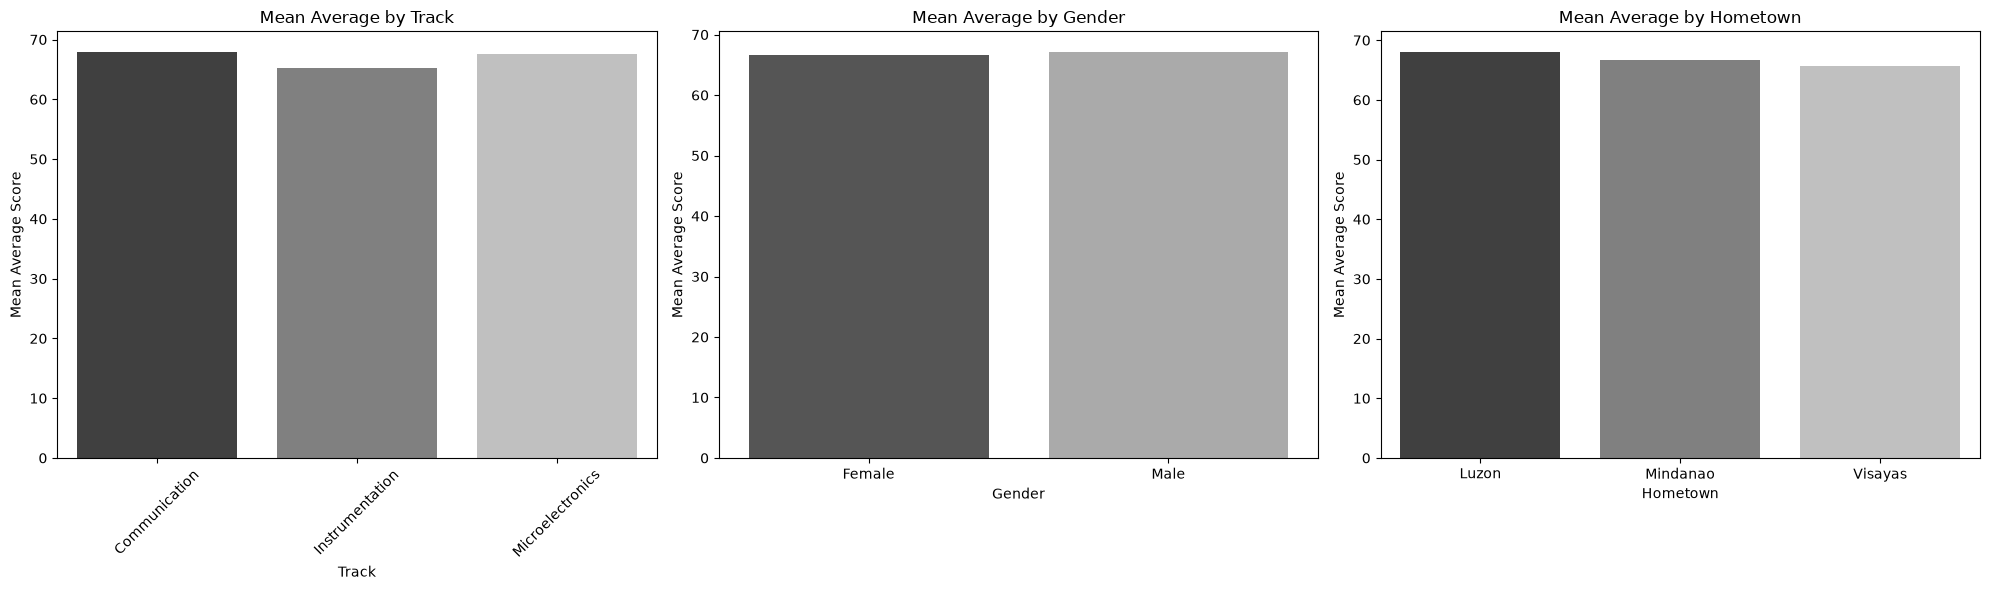

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x='Track', y='Average', data=mean_average_by_track, ax=axes[0], palette='gray', hue='Track', legend=False)
axes[0].set_title('Mean Average by Track')
axes[0].set_ylabel('Mean Average Score')
axes[0].set_xlabel('Track')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Gender', y='Average', data=mean_average_by_gender, ax=axes[1], palette='gray', hue='Gender', legend=False)
axes[1].set_title('Mean Average by Gender')
axes[1].set_ylabel('Mean Average Score')
axes[1].set_xlabel('Gender')

sns.barplot(x='Hometown', y='Average', data=mean_average_by_hometown, ax=axes[2], palette='gray', hue='Hometown', legend=False)
axes[2].set_title('Mean Average by Hometown')
axes[2].set_ylabel('Mean Average Score')
axes[2].set_xlabel('Hometown')

plt.tight_layout()
plt.show()

In [36]:
highest_track = mean_average_by_track.loc[mean_average_by_track['Average'].idxmax()]
highest_gender = mean_average_by_gender.loc[mean_average_by_gender['Average'].idxmax()]
highest_hometown = mean_average_by_hometown.loc[mean_average_by_hometown['Average'].idxmax()]

print(f"With the Average score of 67.975, {highest_track['Track']} has the highest sample mean in the Track category.")
print(f"With the Average score of 67.183333, {highest_gender['Gender']} students have the highest sample mean in the Gender category.")
print(f"Lastly for the Hometown catgeory, with the Average score of 68.083333, {highest_hometown['Hometown']} has the highest sample mean.")

With the Average score of 67.975, Communication has the highest sample mean in the Track category.
With the Average score of 67.183333, Male students have the highest sample mean in the Gender category.
Lastly for the Hometown catgeory, with the Average score of 68.083333, Luzon has the highest sample mean.
